<a href="https://colab.research.google.com/github/AmanuelDaget/Brain-Tumor-Detection-on-MRI-Using-Transfer-Learning-with-VGG16/blob/main/VGG_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Brain Tumor classification using VGG-16**

In [11]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import models, transforms, datasets
from PIL import Image
from matplotlib import pyplot as plt
import cv2
from torchvision.datasets import ImageFolder

# **DATA PREPROCESSING**

**Dataset**

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/brain-tumor-detection-dataset'

**Define Parameters**

In [20]:
BATCH_SIZE = 16
TEST_SPLIT = 0.2
EPOCHS = 20
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [21]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
])

def clahe_loader(path):
    # Read image as grayscale
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Check if image was loaded successfully. If not, return a placeholder.
    if img is None:
        print(f"Warning: Could not load image at {path}. Returning a blank placeholder.")
        # Return a black RGB image of target size to avoid further errors
        return Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0)
    enhanced = clahe.apply(img)
    # Convert to RGB
    rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    # Convert to PIL.Image
    pil_img = Image.fromarray(rgb)
    return pil_img

# Use the custom loader in ImageFolder:
train_dataset = ImageFolder(DATA_DIR, transform=train_transforms, loader=clahe_loader)
# Then split as before

**Transforms**

In [22]:
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
])

**Dataset and Train/Test Split**

In [23]:
# Load using ImageFolder (expects subfolders per class)
# full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)
full_dataset = ImageFolder(DATA_DIR, transform=train_transforms, loader=clahe_loader)

num_test = int(len(full_dataset) * TEST_SPLIT)
num_train = len(full_dataset) - num_test
train_dataset, test_dataset = random_split(full_dataset, [num_train, num_test], generator=torch.Generator().manual_seed(42))

# Assign test transforms to test_dataset (ensures no augmentation on test set)
test_dataset.dataset.transform = test_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

**VGG16 Model Setup**

In [24]:
vgg16 = models.vgg16(pretrained=True)

# Freeze all layers except final classifier
for param in vgg16.parameters():
    param.requires_grad = False

num_features = vgg16.classifier[6].in_features
vgg16.classifier[6] = nn.Linear(num_features, 2)
vgg16 = vgg16.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg16.classifier[6].parameters(), lr=1e-4)

**Training Loop**

In [36]:
# Lists for visualization
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------
    vgg16.train()

    train_loss = 0.0
    train_correct = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = vgg16(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()

    epoch_loss = train_loss / len(train_dataset)
    epoch_acc = train_correct / len(train_dataset)

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Train Acc: {epoch_acc:.4f}"
    )

Epoch [1/20] | Train Loss: 0.2838 | Train Acc: 0.8966
Epoch [2/20] | Train Loss: 0.2972 | Train Acc: 0.8768
Epoch [3/20] | Train Loss: 0.2814 | Train Acc: 0.9113
Epoch [4/20] | Train Loss: 0.2889 | Train Acc: 0.8867
Epoch [5/20] | Train Loss: 0.3089 | Train Acc: 0.8670
Epoch [6/20] | Train Loss: 0.2775 | Train Acc: 0.9015
Epoch [7/20] | Train Loss: 0.2898 | Train Acc: 0.9015
Epoch [8/20] | Train Loss: 0.2815 | Train Acc: 0.8867
Epoch [9/20] | Train Loss: 0.2875 | Train Acc: 0.8916
Epoch [10/20] | Train Loss: 0.3028 | Train Acc: 0.8670
Epoch [11/20] | Train Loss: 0.2608 | Train Acc: 0.9015
Epoch [12/20] | Train Loss: 0.2790 | Train Acc: 0.8867
Epoch [13/20] | Train Loss: 0.2968 | Train Acc: 0.8621
Epoch [14/20] | Train Loss: 0.2805 | Train Acc: 0.8719
Epoch [15/20] | Train Loss: 0.2762 | Train Acc: 0.9113
Epoch [16/20] | Train Loss: 0.2813 | Train Acc: 0.8867
Epoch [17/20] | Train Loss: 0.2734 | Train Acc: 0.9163
Epoch [18/20] | Train Loss: 0.2456 | Train Acc: 0.9163
Epoch [19/20] | Tra

**Testing**

In [37]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ---------------- TESTING ----------------
vgg16.eval()

test_loss = 0.0
test_correct = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = vgg16(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        test_correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Final metrics
test_loss = test_loss / len(test_dataset)
test_acc = test_correct / len(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 0.3263
Test Accuracy: 0.8600


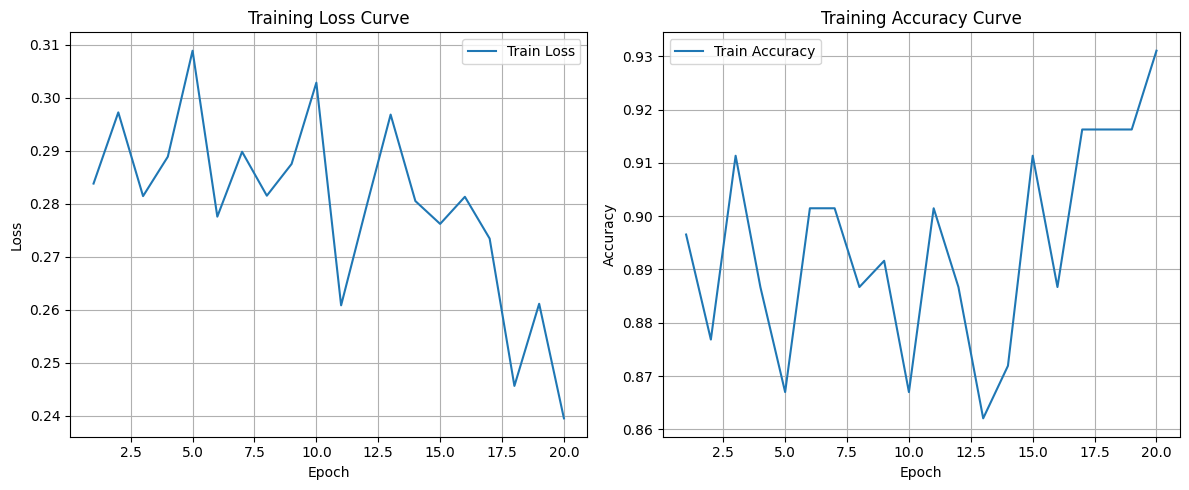

In [38]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# ---------------- LOSS CURVE ----------------
plt.subplot(1, 2, 1)

plt.plot(epochs_range, train_losses, label='Train Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')

plt.legend()
plt.grid(True)


# ---------------- ACCURACY CURVE ----------------
plt.subplot(1, 2, 2)

plt.plot(epochs_range, train_accuracies, label='Train Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Curve')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Predict on a Single Image**

In [42]:
def predict_image(img_path, model, class_names):

    model.eval()

    img = Image.open(img_path).convert("RGB")

    img = test_transforms(img)

    img = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        output = model(img)

        _, pred = torch.max(output, 1)

    prediction = class_names[pred.item()]

    print(f"Prediction: {prediction}")

    return prediction

# Example usage:
class_names = full_dataset.classes
predict_image(os.path.join(DATA_DIR, 'yes', 'Y1.jpg'), vgg16, class_names)

Prediction: yes


'yes'

**Confusion Matrix**

In [46]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

vgg16.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = vgg16(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---------------- CLASSIFICATION REPORT ----------------
print("Classification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=full_dataset.classes
    )
)



Classification Report:

              precision    recall  f1-score   support

          no       0.80      0.75      0.77        16
         yes       0.89      0.91      0.90        34

    accuracy                           0.86        50
   macro avg       0.84      0.83      0.84        50
weighted avg       0.86      0.86      0.86        50

